# xRFM Benchmark Pipeline

Pipeline: **Setup → Select Dataset → Load/Split → Tune Hyperparams → Final Train → Evaluate → Interpretability → Learning Curve**

- Uses the **official xRFM library** directly (`pip install xrfm`, github.com/dmbeaglehole/xRFM)
- Preprocessing follows README recommendations: StandardScaler for numerics,
  OneHotEncoder for categoricals with `categorical_info` passed to xRFM
- Train / Val / Test split: **60 / 20 / 20** with `SEED = 42`
- `RUN_MODE` switch: `"single"` (fast smoke test) or `"all"` (full benchmark)

In [1]:
# ========== 1. SETUP ==========

import json, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                            r2_score, root_mean_squared_error)
from IPython.display import display

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# ---------- USER SWITCHES ----------
RUN_MODE          = "all"              # "single" or "all"
SINGLE_DATASET_ID = "bank_marketing"      # only used when RUN_MODE == "single"
TEST_SIZE         = 0.2                   # held-out test set: 20%
VAL_SIZE          = 0.25                  # val fraction of train+val → gives 60/20/20 split

# Device selection
# ─────────────────────────────────────────────────────────────────────────────
# Force GPU whenever CUDA is available (per current experiment plan).
# If CUDA is unavailable, fallback to CPU.
# ─────────────────────────────────────────────────────────────────────────────
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def pick_device(n_train):
    """Always use GPU when available; otherwise use CPU."""
    return "cuda" if DEVICE == "cuda" else "cpu"

print(f"Run mode      : {RUN_MODE}")
print(f"Device        : {DEVICE}  ({'GPU forced' if DEVICE=='cuda' else 'no GPU / fallback CPU'})")
print(f"Split (approx): train≈60%  val≈20%  test≈20%  (seed={SEED})")

Run mode      : all
Device        : cuda  (GPU forced)
Split (approx): train≈60%  val≈20%  test≈20%  (seed=42)


In [2]:
# ========== 1b. SETUP – Official xRFM Library ==========
#
# Using the official xRFM library directly as required:
#   pip install xrfm  (github.com/dmbeaglehole/xRFM)
#
# The xRFM class is sklearn-compatible:
#   model.fit(X, y, X_val, y_val)
#   model.predict(X)
#   model.predict_proba(X)
#
# Hyperparameters are passed via rfm_params dict:
#   rfm_params = {'fit': {'iters': ..., 'reg': ...},
#                 'model': {'kernel': 'l2', ...}}

try:
    from xrfm import xRFM
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xrfm"])
    from xrfm import xRFM

print("xRFM (official library) ready.")

xRFM (official library) ready.


In [3]:
# ========== 2. SELECT DATASET(S) ==========

with open(PROJECT_ROOT / "Datasets.json", encoding="utf-8") as f:
    CATALOG = {d["id"]: d for d in json.load(f)}

if RUN_MODE == "single":
    assert SINGLE_DATASET_ID in CATALOG, f"{SINGLE_DATASET_ID} not in Datasets.json"
    SELECTED = [SINGLE_DATASET_ID]
else:
    SELECTED = list(CATALOG.keys())

print(f"Datasets to run ({len(SELECTED)}): {SELECTED}")

Datasets to run (5): ['bank_marketing', 'rt_iot_2022', 'dry_bean', 'parkinsons_telemonitoring', 'online_news_popularity']


In [4]:
# ========== 3. LOAD / SPLIT / PREPROCESS ==========
#
# Preprocessing follows the official xRFM README recommendations:
#   - Standardize numerical columns with StandardScaler
#   - One-hot encode categoricals; do NOT standardize them
#   - Build categorical_info dict for xRFM (numerical_indices,
#     categorical_indices, categorical_vectors)

def load_and_split(cfg: dict):
    """Read CSV → clean → split → preprocess → return numpy arrays + categorical_info."""
    path = PROJECT_ROOT / cfg["csv_path"]
    assert str(path).lower().endswith(".csv"), "Only CSV files are accepted."

    df = pd.read_csv(path)

    print(f"Loaded '{cfg['id']}' with {len(df)} rows and {len(df.columns)} columns.")

    df.columns = [str(c).strip() for c in df.columns]

    target_col = cfg["target"]
    if target_col not in df.columns:
        target_map = {str(c).strip().lower(): c for c in df.columns}
        mapped = target_map.get(str(target_col).strip().lower())
        if mapped is None:
            raise KeyError(f"Target column '{target_col}' not found in CSV: {path}")
        target_col = mapped

    drop_cols = []
    col_map = {str(c).strip().lower(): c for c in df.columns}
    for c in cfg.get("drop_cols", []):
        mapped = col_map.get(str(c).strip().lower())
        if mapped is not None and mapped != target_col:
            drop_cols.append(mapped)
    if drop_cols:
        df = df.drop(columns=drop_cols)

    X = df.drop(columns=target_col)
    y = df[target_col]

    cat_cols = []
    for c in cfg.get("cat_cols", []):
        mapped = col_map.get(str(c).strip().lower())
        if mapped is not None and mapped in X.columns:
            cat_cols.append(mapped)
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]) and c not in cat_cols:
            cat_cols.append(c)
    num_cols = [c for c in X.columns if c not in cat_cols]

    for c in num_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    if num_cols and X[num_cols].isna().any().any():
        X[num_cols] = X[num_cols].fillna(X[num_cols].median())

    le = None
    if cfg["task"] == "clf":
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y), index=y.index)

    strat = y if cfg["task"] == "clf" else None
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED, stratify=strat)
    strat_tv = y_tv if cfg["task"] == "clf" else None
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=VAL_SIZE, random_state=SEED, stratify=strat_tv)

    # ── Preprocessing (following xRFM README) ──────────────────────────────
    # Fit scaler on train numerics only
    scaler = StandardScaler()
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore") if cat_cols else None

    X_num_train = scaler.fit_transform(X_train[num_cols]).astype(np.float32) if num_cols else np.zeros((len(X_train), 0), dtype=np.float32)
    X_num_val   = scaler.transform(X_val[num_cols]).astype(np.float32) if num_cols else np.zeros((len(X_val), 0), dtype=np.float32)
    X_num_test  = scaler.transform(X_test[num_cols]).astype(np.float32) if num_cols else np.zeros((len(X_test), 0), dtype=np.float32)

    if ohe is not None:
        X_cat_train = ohe.fit_transform(X_train[cat_cols]).astype(np.float32)
        X_cat_val   = ohe.transform(X_val[cat_cols]).astype(np.float32)
        X_cat_test  = ohe.transform(X_test[cat_cols]).astype(np.float32)
    else:
        X_cat_train = np.zeros((len(X_train), 0), dtype=np.float32)
        X_cat_val   = np.zeros((len(X_val), 0), dtype=np.float32)
        X_cat_test  = np.zeros((len(X_test), 0), dtype=np.float32)

    # Concatenate: numericals first, then categoricals (as per README)
    X_train_np = np.hstack([X_num_train, X_cat_train])
    X_val_np   = np.hstack([X_num_val, X_cat_val])
    X_test_np  = np.hstack([X_num_test, X_cat_test])

    if cfg["task"] == "clf":
        y_train_np = y_train.to_numpy(dtype=np.int64)
        y_val_np   = y_val.to_numpy(dtype=np.int64)
        y_test_np  = y_test.to_numpy(dtype=np.int64)
        y_scaler   = None
    else:
        y_train_np = y_train.to_numpy(dtype=np.float32)
        y_val_np   = y_val.to_numpy(dtype=np.float32)
        y_test_np  = y_test.to_numpy(dtype=np.float32)

        y_scaler = StandardScaler()
        y_train_np = y_scaler.fit_transform(y_train_np.reshape(-1, 1)).ravel().astype(np.float32)
        y_val_np   = y_scaler.transform(y_val_np.reshape(-1, 1)).ravel().astype(np.float32)
        y_test_np  = y_scaler.transform(y_test_np.reshape(-1, 1)).ravel().astype(np.float32)

    # ── Build categorical_info for xRFM (per README) ──────────────────────
    n_num = X_num_train.shape[1]
    categorical_indices = []
    categorical_vectors = []
    if ohe is not None:
        start = n_num
        for cats in ohe.categories_:
            cat_len = len(cats)
            idxs = torch.arange(start, start + cat_len, dtype=torch.long)
            categorical_indices.append(idxs)
            categorical_vectors.append(torch.eye(cat_len, dtype=torch.float32))
            start += cat_len

    numerical_indices = torch.arange(0, n_num, dtype=torch.long)

    categorical_info = dict(
        numerical_indices=numerical_indices,
        categorical_indices=categorical_indices,
        categorical_vectors=categorical_vectors,
    ) if categorical_indices else None

    # ── Feature names ─────────────────────────────────────────────────────
    feature_names = [f"num__{c}" for c in num_cols]
    if ohe is not None:
        for col, cats in zip(cat_cols, ohe.categories_):
            feature_names.extend([f"cat__{col}_{cat}" for cat in cats])

    info = {"n_samples": len(df), "n_num": len(num_cols),
            "n_cat": len(cat_cols), "label_encoder": le, "y_scaler": y_scaler,
            "feature_names": feature_names, "categorical_info": categorical_info}
    return X_train_np, X_val_np, X_test_np, y_train_np, y_val_np, y_test_np, info

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def summarize_direction(direction, feature_names=None, topk=3):
    v = to_numpy(direction)

    if feature_names is None or len(feature_names) != len(v):
        feature_names = [f"f{i}" for i in range(len(v))]

    idx = np.argsort(np.abs(v))[::-1][:topk]
    return "\n".join([f"{feature_names[i]}: {v[i]:.2f}" for i in idx])

def count_leaves(node):
    if node["type"] == "leaf":
        return 1
    return count_leaves(node["left"]) + count_leaves(node["right"])

def assign_positions(node, x_left=0.0, x_right=1.0, y=1.0, y_step=0.25, pos=None, node_id="0"):
    if pos is None:
        pos = {}

    x_mid = (x_left + x_right) / 2
    pos[node_id] = (x_mid, y, node)

    if node["type"] == "split":
        left_leaves = count_leaves(node["left"])
        right_leaves = count_leaves(node["right"])
        total = left_leaves + right_leaves

        split_x = x_left + (x_right - x_left) * (left_leaves / total)

        assign_positions(node["left"], x_left, split_x, y - y_step, y_step, pos, node_id + "L")
        assign_positions(node["right"], split_x, x_right, y - y_step, y_step, pos, node_id + "R")

    return pos

def node_text(node, feature_names=None, topk=3, node_id=""):
    if node["type"] == "split":
        split_point = float(node["split_point"].detach().cpu().item())
        temp = node.get("adaptive_temp_scaling", None)
        direction_text = summarize_direction(node["split_direction"], feature_names, topk=topk)

        return (
            f"Split {node_id}\n"
            f"t = {split_point:.3f}\n"
            f"temp = {temp:.2f}\n"
            f"{direction_text}"
        )
    else:
        n_train = len(node.get("train_indices", []))
        return (
            f"Leaf {node_id}\n"
            f"n = {n_train}"
        )

def draw_xrfm_tree(tree, title=None, feature_names=None, topk=3, figsize=(14, 6)):
    pos = assign_positions(tree, x_left=0.0, x_right=1.0, y=0.88, y_step=0.14)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=14, pad=30)

    # draw edges
    for node_id, (x, y, node) in pos.items():
        if node["type"] == "split":
            for child_suffix, edge_label in [("L", "L"), ("R", "R")]:
                child_id = node_id + child_suffix
                if child_id in pos:
                    cx, cy, _ = pos[child_id]
                    ax.plot([x, cx], [y, cy], "k-", linewidth=1.2)
                    ax.text(
                        (x + cx) / 2,
                        (y + cy) / 2 + 0.02,
                        edge_label,
                        ha="center",
                        va="center",
                        fontsize=9
                    )

    # draw nodes
    for node_id, (x, y, node) in pos.items():
        text = node_text(node, feature_names=feature_names, topk=topk, node_id=node_id)

        if node["type"] == "split":
            bbox = dict(boxstyle="round,pad=0.35", facecolor="#E8F0FE", edgecolor="black")
        else:
            bbox = dict(boxstyle="round,pad=0.35", facecolor="#EAF7EA", edgecolor="black")

        ax.text(x, y, text, ha="center", va="center", fontsize=10, bbox=bbox)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
    return fig, ax

In [6]:
# ========== HYPERPARAMETER TUNING (per-dataset, validation-based) ==========
#
# Parameters tuned
#   iters          – RFM iterations per leaf node
#                    (controls depth of feature learning; more = richer AGOP)
#   reg            – regularisation for the kernel ridge solver
#                    (higher = more conservative / less overfit)
#
# Search space rationale
#   • iters ∈ {3, 5, 8}      → "conservative / moderate / deep" feature learning
#   • reg   ∈ {1e-4, …, 1e-1} → spans two orders of magnitude either side of default (1e-3)
#
# Three-tier grid (matched to expected training time per run):
#   FULL_GRID   – bank_marketing, dry_bean, parkinsons  (fast; < 30 s / run)
#   MEDIUM_GRID – online_news_popularity                (moderate; ~30–90 s / run)
#   SMALL_GRID  – rt_iot_2022                           (slow; ~15 min / run)
#
# Protocol
#   • Train on X_train only; evaluate on X_val; test set NEVER touched during tuning
#   • Classification metric : AUC-ROC  (falls back to Accuracy on failure)
#   • Regression metric     : −RMSE    (higher is always better)
#   • Best params per dataset saved to outputs/xrfm_best_params.json

import itertools, json

# ── Search grids ──────────────────────────────────────────────────────────────

# 12 combinations: fast datasets
FULL_GRID = {
    "iters": [3, 5, 8],               # conservative / moderate / deep
    "reg":   [1e-4, 1e-3, 1e-2, 1e-1],
}

# 6 combinations: medium-speed dataset (online_news is large but CPU-manageable)
MEDIUM_GRID = {
    "iters": [3, 5],
    "reg":   [1e-3, 1e-2, 1e-1],
}

# 4 combinations: RT-IoT 2022 (~15 min / run on CPU → keep to ≤ 1 h total)
SMALL_GRID = {
    "iters": [3, 5],
    "reg":   [1e-2, 1e-1],
}

# Map each dataset to its grid
GRID_MAP = {
    "bank_marketing":          FULL_GRID,
    "dry_bean":                FULL_GRID,
    "parkinsons_telemonitoring": FULL_GRID,
    "online_news_popularity":  MEDIUM_GRID,
    "rt_iot_2022":             SMALL_GRID,
}


def make_grid(param_dict):
    keys   = list(param_dict.keys())
    combos = list(itertools.product(*param_dict.values()))
    return [dict(zip(keys, c)) for c in combos]


def build_xrfm(task, device, categorical_info=None, iters=3, reg=1e-3):
    """Create an xRFM model with the given hyperparams."""
    rfm_params = {
        'model': {
            'kernel': 'l2',
            'bandwidth': 5.0,
            'exponent': 1.0,
            'diag': False,
            'bandwidth_mode': 'constant',
        },
        'fit': {
            'reg': reg,
            'iters': iters,
            'verbose': False,
            # Avoid NoneType-to bug in some tree leaves.
            'early_stop_rfm': False,
        },
    }
    # 'auc' can fail in leaf-level subsets with a single class; use accuracy for stability.
    metric = 'accuracy' if task == 'clf' else 'mse'
    return xRFM(
        rfm_params=rfm_params,
        device=torch.device(device),
        tuning_metric=metric,
        categorical_info=categorical_info,
    )


def compute_val_score(model, X_val, y_val, task):
    """Return a scalar score; higher is always better."""
    if task == "clf":
        try:
            proba = to_numpy(model.predict_proba(X_val))
            if proba.ndim == 1:
                return roc_auc_score(y_val, proba)
            if proba.shape[1] == 2:
                return roc_auc_score(y_val, proba[:, 1])
            return roc_auc_score(y_val, proba, multi_class="ovr")
        except Exception:
            return accuracy_score(y_val, to_numpy(model.predict(X_val)))
    else:
        return -root_mean_squared_error(y_val, to_numpy(model.predict(X_val)))


TUNING_RESULTS = []
BEST_PARAMS    = {}

for ds_id in SELECTED:
    cfg  = CATALOG[ds_id]
    grid = make_grid(GRID_MAP.get(ds_id, FULL_GRID))

    print(f"\n{'='*65}")
    print(f"Tuning: {cfg['label']}  ({len(grid)} combinations)")
    print(f"  iters ∈ {GRID_MAP.get(ds_id, FULL_GRID)['iters']}")
    print(f"  reg   ∈ {GRID_MAP.get(ds_id, FULL_GRID)['reg']}")

    X_train, X_val, X_test, y_train, y_val, y_test, info = load_and_split(cfg)
    _ds_device = pick_device(len(X_train))
    cat_info = info.get("categorical_info")
    print(f"  device: {_ds_device}  (n_train={len(X_train)})")

    best_score  = -np.inf
    best_params = grid[0]

    for idx, params in enumerate(grid):
        t0 = time.time()
        mdl = build_xrfm(cfg["task"], _ds_device, categorical_info=cat_info, **params)

        mdl.fit(X_train, y_train, X_val, y_val)
        score   = compute_val_score(mdl, X_val, y_val, cfg["task"])
        elapsed = time.time() - t0

        TUNING_RESULTS.append({
            "dataset":   cfg["label"],
            "task":      cfg["task"],
            "iters":     params["iters"],
            "reg":       params["reg"],
            "val_score": round(score, 4),
            "train_sec": round(elapsed, 2),
        })

        is_best = score > best_score
        marker  = " ← BEST" if is_best else ""
        print(f"  [{idx+1:2d}/{len(grid)}] iters={params['iters']:>2}  "
              f"reg={params['reg']:.0e}  "
              f"val={score:.4f}  {elapsed:.1f}s{marker}")

        if is_best:
            best_score  = score
            best_params = params.copy()

        # Free GPU memory after each trial to prevent OOM accumulation
        del mdl
        if _ds_device == "cuda":
            torch.cuda.empty_cache()

    BEST_PARAMS[ds_id] = best_params
    print(f"\n  >>> BEST: iters={best_params['iters']}  reg={best_params['reg']:.0e}"
          f"  val={best_score:.4f}")

# ── Save ──────────────────────────────────────────────────────────────────────
tuning_df        = pd.DataFrame(TUNING_RESULTS)
ts               = datetime.now().strftime("%Y%m%d_%H%M%S")
tuning_path      = OUTPUT_DIR / f"xrfm_tuning_{ts}.csv"
best_params_path = OUTPUT_DIR / "xrfm_best_params.json"

tuning_df.to_csv(tuning_path, index=False)
with open(best_params_path, "w") as f:
    json.dump(BEST_PARAMS, f, indent=2)

print(f"\nTuning complete.")
print(f"  Tuning table  → {tuning_path}")
print(f"  Best params   → {best_params_path}")
display(tuning_df)


Tuning: Bank Marketing  (12 combinations)
  iters ∈ [3, 5, 8]
  reg   ∈ [0.0001, 0.001, 0.01, 0.1]
Loaded 'bank_marketing' with 11162 rows and 17 columns.
  device: cuda  (n_train=6696)
None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 6696, d: 51, and nval: 2233
Using cheap batch size
Optimal M batch size: 787
Using SVD
Time taken for round 0: 0.7443835735321045 seconds
Using cheap batch size
Optimal M batch size: 787
Using SVD
Time taken for round 1: 0.18193483352661133 seconds
Using cheap batch size
Optimal M batch size: 787
Using SVD
Time taken for round 2: 0.17635560035705566 seconds
Tree has no split, stopping training


Building trees:   0%|          | 0/1 [00:01<?, ?it/s]


Using hard routing for tree prediction
  [ 1/12] iters= 3  reg=1e-04  val=0.9024  1.5s ← BEST
None
Fitting xRFM with 1 trees and 0 iterations per tree


...

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([13328, 59]) y_train torch.Size([13328, 1]) X_val torch.Size([702, 59]) y_val torch.Size([702, 1])
Fitting RFM with ntrain: 13328, d: 59, and nval: 702
Using cheap batch size
Optimal M batch size: 787
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 14272, d: 59, and nval: 4044
Using cheap batch size
Optimal M batch size: 782
Using SVD
Time taken for round 0: 0.9364914894104004 seconds
Using cheap batch size
Optimal M batch size: 782
Using SVD
Time taken for round 1: 0.9597792625427246 seconds
Using cheap batch size
Optimal M batch size: 782
Using SVD
Time taken for round 2: 0.9471664428710938 seconds
Using cheap batch size
Optimal M batch size: 782
Using SVD
Time taken for round 3: 0.9500253200531006 seconds
Using cheap batch size
Optimal M batch size: 782
Using SVD
Time taken for round 4: 0.9684393405914307 seconds
Refilling validation set, because at lea

Tuning split temperature: 100%|██████████| 36/36 [00:02<00:00, 15.97it/s]


Selected split_temperature=4.500000000000001 based on validation mse=1.708003
Using soft routing for tree prediction
  [ 6/6] iters= 5  reg=1e-01  val=-1.3069  14.3s

  >>> BEST: iters=3  reg=1e-01  val=-1.2985

Tuning complete.
  Tuning table  → c:\Users\SPY\Desktop\comp9417\group_project\outputs\xrfm_tuning_20260420_223931.csv
  Best params   → c:\Users\SPY\Desktop\comp9417\group_project\outputs\xrfm_best_params.json


,dataset,task,iters,reg,val_score,train_sec
0,Bank Marketing,clf,3,0.0001,0.9024,1.53
1,Bank Marketing,clf,3,0.0010,0.9027,0.65
2,Bank Marketing,clf,3,0.0100,0.9073,0.65
3,Bank Marketing,clf,3,0.1000,0.9138,0.64
4,Bank Marketing,clf,5,0.0001,0.9024,0.98
5,Bank Marketing,clf,5,0.0010,0.9027,0.98
6,Bank Marketing,clf,5,0.0100,0.9073,0.97
7,Bank Marketing,clf,5,0.1000,0.9138,0.97
8,Bank Marketing,clf,8,0.0001,0.9024,1.45
9,Bank Marketing,clf,8,0.0010,0.9027,1.46


In [7]:
# ========== FINAL TRAINING WITH BEST PARAMS + TEST EVALUATION ==========
#
# Protocol
#   • Load best params from xrfm_best_params.json (produced by tuning cell)
#   • Train on X_train; pass X_val for early-stopping / temperature tuning only
#   • Report ALL metrics on held-out X_test (NEVER used during tuning)
#   • Metrics: Accuracy + AUC-ROC (clf) | RMSE + R² (reg)
#   • Also record training time and per-sample inference time
#
# Outputs
#   • FINAL_MODELS dict  – reused by interpretability and learning-curve cells
#   • outputs/xrfm_final_results_<timestamp>.csv

import json

best_params_path = OUTPUT_DIR / "xrfm_best_params.json"
if not best_params_path.exists():
    raise FileNotFoundError(
        "Run the Hyperparameter Tuning cell first to generate xrfm_best_params.json")

with open(best_params_path) as f:
    BEST_PARAMS_LOADED = json.load(f)

print("Loaded best params per dataset:")
for ds_id, params in BEST_PARAMS_LOADED.items():
    print(f"  {ds_id}: iters={params.get('iters')}  reg={params.get('reg'):.0e}"
          if params.get('reg') is not None else f"  {ds_id}: {params}")

FINAL_MODELS  = {}
FINAL_RESULTS = []
t_total       = time.time()

for i, ds_id in enumerate(SELECTED, 1):
    cfg    = CATALOG[ds_id]
    params = BEST_PARAMS_LOADED.get(ds_id, {})

    print(f"\n[{i}/{len(SELECTED)}] {cfg['label']}  |  best params: {params}")

    X_train, X_val, X_test, y_train, y_val, y_test, info = load_and_split(cfg)
    _ds_device = pick_device(len(X_train))
    cat_info = info.get("categorical_info")
    print(f"  device: {_ds_device}  (n_train={len(X_train)})")

    model = build_xrfm(cfg["task"], _ds_device, categorical_info=cat_info, **params)

    # ---- Train (val passed for internal early-stopping, not for metric selection) ----
    train_t0  = time.time()
    model.fit(X_train, y_train, X_val, y_val)
    train_sec = time.time() - train_t0

    # ---- Inference timing on test set ----
    infer_t0   = time.time()
    y_pred_raw = model.predict(X_test)
    infer_ms   = (time.time() - infer_t0) / max(len(X_test), 1) * 1000
    y_pred     = to_numpy(y_pred_raw)

    # ---- Test-set metrics ----
    metrics = {}
    if cfg["task"] == "clf":
        metrics["accuracy"] = round(accuracy_score(y_test, y_pred), 4)
        metrics["f1_macro"] = round(f1_score(y_test, y_pred, average="macro"), 4)
        try:
            proba = to_numpy(model.predict_proba(X_test))
            if proba.ndim == 1:
                metrics["auc"] = round(roc_auc_score(y_test, proba), 4)
            elif proba.shape[1] == 2:
                metrics["auc"] = round(roc_auc_score(y_test, proba[:, 1]), 4)
            else:
                metrics["auc"] = round(roc_auc_score(y_test, proba, multi_class="ovr"), 4)
        except Exception:
            metrics["auc"] = float("nan")
    else:
        metrics["rmse"] = round(root_mean_squared_error(y_test, y_pred), 4)
        metrics["r2"]   = round(r2_score(y_test, y_pred), 4)
        ys = info.get("y_scaler")
        if ys is not None:
            y_test_orig = ys.inverse_transform(y_test.reshape(-1, 1)).ravel()
            y_pred_orig = ys.inverse_transform(y_pred.reshape(-1, 1)).ravel()
            metrics["rmse_original"] = round(
                root_mean_squared_error(y_test_orig, y_pred_orig), 4)

    row = {
        "dataset":             cfg["label"],
        "task":                cfg["task"],
        "n_samples":           info["n_samples"],
        "n_features":          info["n_num"] + info["n_cat"],
        "best_iters":          str(params.get("iters", "default")),
        "best_reg":            params.get("reg", "default"),
        "train_sec":           round(train_sec, 2),
        "infer_ms_per_sample": round(infer_ms, 4),
        **metrics,
    }
    FINAL_RESULTS.append(row)

    FINAL_MODELS[ds_id] = {
        "model":  model,
        "info":   info,
        "splits": (X_train, X_val, X_test, y_train, y_val, y_test),
    }
    print(f"  train={train_sec:.1f}s  infer={infer_ms:.4f}ms/sample  |  {metrics}")

# ---- Save ----
final_df   = pd.DataFrame(FINAL_RESULTS)
final_path = OUTPUT_DIR / f"xrfm_final_results_{datetime.now():%Y%m%d_%H%M%S}.csv"
final_df.to_csv(final_path, index=False)

total_min = (time.time() - t_total) / 60
print(f"\nTotal wall-time: {total_min:.1f} min  |  Saved → {final_path}")
display(final_df)

Loaded best params per dataset:
  bank_marketing: iters=3  reg=1e-01
  rt_iot_2022: iters=3  reg=1e-01
  dry_bean: iters=3  reg=1e-01
  parkinsons_telemonitoring: iters=8  reg=1e-04
  online_news_popularity: iters=3  reg=1e-01

[1/5] Bank Marketing  |  best params: {'iters': 3, 'reg': 0.1}
Loaded 'bank_marketing' with 11162 rows and 17 columns.
  device: cuda  (n_train=6696)
None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 6696, d: 51, and nval: 2233
Using cheap batch size
Optimal M batch size: 787
Using SVD
Time taken for round 0: 0.17388629913330078 seconds
Using cheap batch size
Optimal M batch size: 787
Using SVD
Time taken for round 1: 0.16911649703979492 seconds
Using cheap batch size
Optimal M batch size: 787
Using SVD
Time taken for round 2: 0.1720139980316162 seconds


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Tree has no split, stopping training
Using hard routing for tree prediction
Using hard routing for tree prediction
  train=0.6s  infer=0.0027ms/sample  |  {'accuracy': 0.8576, 'f1_macro': 0.8576, 'auc': 0.9194}

[2/5] RT-IoT 2022  |  best params: {'iters': 3, 'reg': 0.1}


...

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([13044, 59]) y_train torch.Size([13044, 1]) X_val torch.Size([687, 59]) y_val torch.Size([687, 1])
Fitting RFM with ntrain: 13044, d: 59, and nval: 687
Using cheap batch size
Optimal M batch size: 754
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 14272, d: 59, and nval: 3964
Using cheap batch size
Optimal M batch size: 754
Using SVD
Time taken for round 0: 0.9313082695007324 seconds
Using cheap batch size
Optimal M batch size: 754
Using SVD
Time taken for round 1: 0.9263978004455566 seconds
Using cheap batch size
Optimal M batch size: 754
Using SVD
Time taken for round 2: 0.9234447479248047 seconds
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 14271, d: 59, and nval: 3965
Using cheap batch size
Optimal M batch size: 754
Using SVD
Time taken for round 0: 0.899498701095581 seconds
Using cheap batch size
Optima

Tuning split temperature: 100%|██████████| 36/36 [00:02<00:00, 16.56it/s]

Selected split_temperature=3.8626109693890935 based on validation mse=1.696409
Using soft routing for tree prediction
  train=10.0s  infer=0.0092ms/sample  |  {'rmse': 0.9876, 'r2': 0.0421, 'rmse_original': 10751.4775}

Total wall-time: 4.7 min  |  Saved → c:\Users\SPY\Desktop\comp9417\group_project\outputs\xrfm_final_results_20260420_224416.csv


,dataset,task,n_samples,n_features,best_iters,best_reg,train_sec,infer_ms_per_sample,accuracy,f1_macro,auc,rmse,r2,rmse_original
0,Bank Marketing,clf,11162,16,3,0.1000,0.64,0.0027,0.8576,0.8576,0.9194,NaN,NaN,NaN
1,RT-IoT 2022,clf,123117,83,3,0.1000,268.12,0.0125,0.9972,0.9699,0.9847,NaN,NaN,NaN
2,Dry Bean,clf,13611,16,3,0.1000,1.29,0.0031,0.9269,0.9383,0.9929,NaN,NaN,NaN
3,Parkinsons Telemonitoring,reg,5875,20,8,0.0001,0.41,0.0020,NaN,NaN,NaN,0.0377,0.9985,0.4055
4,Online News Popularity,reg,39644,59,3,0.1000,9.98,0.0092,NaN,NaN,NaN,0.9876,0.0421,10751.4775


Reusing tuned Bank Marketing model from FINAL_MODELS.
Preprocessed feature count: 51
  AGOP extracted from 1 leaf node(s).
  Top-3 AGOP features: [3, 42, 38]
  PCA – explained variance ratio (PC1): 0.153
  Mutual information computed.
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for t

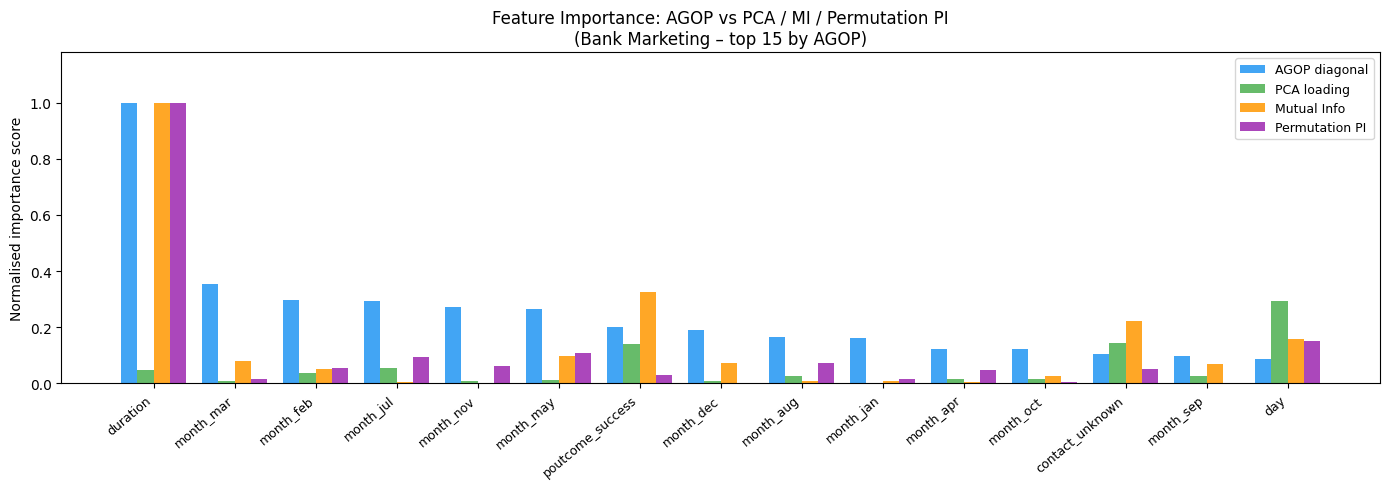

Bar chart saved.


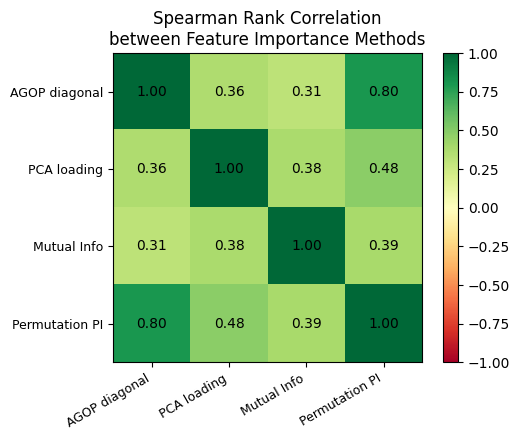

Correlation heatmap saved.


,short_name,agop,pca_loading,mutual_info,permutation_pi
0,duration,1.000000,0.048941,1.000000,1.000000
1,month_mar,0.354528,0.009625,0.079192,0.015277
2,month_feb,0.296397,0.035491,0.049494,0.055851
3,month_jul,0.291859,0.054053,0.005755,0.093359
4,month_nov,0.273263,0.007812,0.000000,0.062870
5,month_may,0.264463,0.013744,0.097324,0.107209
6,poutcome_success,0.200094,0.138936,0.324192,0.028182
7,month_dec,0.188722,0.007152,0.071345,0.002826
8,month_aug,0.166939,0.027938,0.007101,0.072175
9,month_jan,0.161591,0.001905,0.010057,0.016243


In [9]:
# ========== INTERPRETABILITY COMPARISON: AGOP vs PCA / MI / Permutation Importance ==========
#
# Dataset  : Bank Marketing (binary classification, mixed features)
#
# Methods compared
#   1. AGOP diagonal  – per-leaf M matrix diagonal, averaged across all xRFM leaves
#                       M is the learned feature-importance matrix from the AGOP update
#   2. PCA loadings   – |first principal component| (sklearn.decomposition.PCA)
#   3. Mutual Info    – sklearn.feature_selection.mutual_info_classif
#   4. Permutation PI – sklearn.inspection.permutation_importance (val set, AUC scoring)
#
# Outputs
#   • Bar chart  → outputs/xrfm_interp_barchart.png
#   • Corr heatmap → outputs/xrfm_interp_corr.png
#   • Full table → outputs/xrfm_interpretability_bank.csv

from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import torch

INTERP_DS = "bank_marketing"

# ── Obtain model + data ───────────────────────────────────────────────────────
cfg_bm = CATALOG[INTERP_DS]

if INTERP_DS in FINAL_MODELS:
    bm_bundle = FINAL_MODELS[INTERP_DS]
    bm_model  = bm_bundle["model"]
    bm_info   = bm_bundle["info"]
    X_train_bm, X_val_bm, X_test_bm, y_train_bm, y_val_bm, y_test_bm = bm_bundle["splits"]
    print("Reusing tuned Bank Marketing model from FINAL_MODELS.")
else:
    X_train_bm, X_val_bm, X_test_bm, y_train_bm, y_val_bm, y_test_bm, bm_info = \
        load_and_split(cfg_bm)
    bm_model = build_xrfm("clf", pick_device(len(X_train_bm)),
                           categorical_info=bm_info.get("categorical_info"),
                           iters=5, reg=1e-2)
    bm_model.fit(X_train_bm, y_train_bm, X_val_bm, y_val_bm)
    print("Trained fresh Bank Marketing model (iters=5, reg=0.01).")

feat_names = bm_info["feature_names"]
d          = len(feat_names)
print(f"Preprocessed feature count: {d}")


# ── 1. AGOP diagonal ─────────────────────────────────────────────────────────
def _get_xrfm_tree(model):
    """Retrieve the xRFM tree dict from a fitted xRFM model."""
    try:
        return model.trees[0]
    except (AttributeError, IndexError):
        return None


def extract_agop_diagonal(model, n_features):
    """
    Traverse all leaf nodes of the fitted xRFM tree and collect the
    diagonal of the AGOP matrix M.  M may be:
      • 1-D tensor → already the diagonal
      • 2-D tensor → take np.diag()
    Returns the mean diagonal across leaves (normalised to [0,1]).
    Falls back to uniform scores if no leaf AGOP is found.
    """
    tree = _get_xrfm_tree(model)
    if tree is None:
        print("  Warning: could not locate xRFM tree. Falling back to uniform scores.")
        return np.ones(n_features)

    agop_diags = []

    def traverse(node):
        if node["type"] == "leaf":
            rfm = node["model"]
            M   = getattr(rfm, "M", None)
            if M is None:
                M = getattr(rfm, "agop_best_model", None)
            if M is not None:
                m_np = M.detach().cpu().numpy() if isinstance(M, torch.Tensor) else np.asarray(M)
                if m_np.ndim == 1 and len(m_np) == n_features:
                    agop_diags.append(m_np)
                elif m_np.ndim == 2 and m_np.shape[0] == n_features:
                    agop_diags.append(np.diag(m_np))
        else:
            traverse(node["left"])
            traverse(node["right"])

    traverse(tree)

    if not agop_diags:
        print("  Warning: no leaf AGOP matrices found. Falling back to uniform scores.")
        return np.ones(n_features)

    print(f"  AGOP extracted from {len(agop_diags)} leaf node(s).")
    return np.mean(agop_diags, axis=0)


agop_scores = extract_agop_diagonal(bm_model, d)
print(f"  Top-3 AGOP features: {np.argsort(agop_scores)[::-1][:3].tolist()}")


# ── 2. PCA loadings (|first PC|) ─────────────────────────────────────────────
pca = PCA(n_components=1, random_state=SEED)
pca.fit(X_train_bm)
pca_scores = np.abs(pca.components_[0])
print(f"  PCA – explained variance ratio (PC1): {pca.explained_variance_ratio_[0]:.3f}")


# ── 3. Mutual Information ─────────────────────────────────────────────────────
mi_scores = mutual_info_classif(X_train_bm, y_train_bm, random_state=SEED)
print("  Mutual information computed.")


# ── 4. Permutation Importance (validation set, AUC scoring) ──────────────────
# sklearn.inspection.permutation_importance requires sklearn estimator tags,
# which official xRFM does not implement. Use a manual permutation routine.
def _auc_from_model(m, X, y):
    p = to_numpy(m.predict_proba(X))
    if p.ndim == 1:
        return roc_auc_score(y, p)
    if p.shape[1] == 2:
        return roc_auc_score(y, p[:, 1])
    return roc_auc_score(y, p, multi_class="ovr")


def permutation_importance_manual(model, X, y, n_repeats=10, random_state=SEED):
    rng = np.random.default_rng(random_state)
    X_work = np.array(X, copy=True)
    baseline = _auc_from_model(model, X_work, y)

    importances = np.zeros(X_work.shape[1], dtype=float)
    for j in range(X_work.shape[1]):
        original_col = X_work[:, j].copy()
        drops = []
        for _ in range(n_repeats):
            X_work[:, j] = rng.permutation(original_col)
            perm_score = _auc_from_model(model, X_work, y)
            drops.append(baseline - perm_score)
        X_work[:, j] = original_col
        importances[j] = np.mean(drops)

    return np.clip(importances, 0, None)


pi_scores = permutation_importance_manual(
    bm_model, X_val_bm, y_val_bm, n_repeats=10, random_state=SEED
)
print("  Permutation importance computed.")


# ── Normalise all scores to [0, 1] ───────────────────────────────────────────
def norm01(v):
    v = np.asarray(v, dtype=float)
    r = v - v.min()
    s = r.max()
    return r / s if s > 0 else r

agop_n = norm01(agop_scores)
pca_n  = norm01(pca_scores)
mi_n   = norm01(mi_scores)
pi_n   = norm01(np.clip(pi_scores, 0, None))

importance_df = pd.DataFrame({
    "feature":        feat_names,
    "agop":           agop_n,
    "pca_loading":    pca_n,
    "mutual_info":    mi_n,
    "permutation_pi": pi_n,
})
importance_df["short_name"] = (
    importance_df["feature"]
    .str.replace(r"^(num__|cat__)", "", regex=True)
    .str[:22]
)

interp_path = OUTPUT_DIR / "xrfm_interpretability_bank.csv"
importance_df.to_csv(interp_path, index=False)
print(f"\nFull interpretability table → {interp_path}")


# ── Plot 1: Grouped bar chart – top-15 features by AGOP ──────────────────────
top15       = importance_df.nlargest(15, "agop").reset_index(drop=True)
methods     = ["agop", "pca_loading", "mutual_info", "permutation_pi"]
method_lbls = ["AGOP diagonal", "PCA loading", "Mutual Info", "Permutation PI"]
colours     = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

x     = np.arange(len(top15))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
for j, (m, lbl, c) in enumerate(zip(methods, method_lbls, colours)):
    ax.bar(x + j * width, top15[m], width, label=lbl, color=c, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(top15["short_name"], rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Normalised importance score")
ax.set_title("Feature Importance: AGOP vs PCA / MI / Permutation PI\n"
             "(Bank Marketing – top 15 by AGOP)")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.18)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xrfm_interp_barchart.png", dpi=150)
plt.show()
print("Bar chart saved.")


# ── Plot 2: Spearman rank-correlation heatmap ─────────────────────────────────
scores_mat = importance_df[methods].to_numpy()
corr_mat   = np.zeros((4, 4))
for ri in range(4):
    for ci in range(4):
        corr_mat[ri, ci], _ = spearmanr(scores_mat[:, ri], scores_mat[:, ci])

fig2, ax2 = plt.subplots(figsize=(5.5, 4.5))
im = ax2.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdYlGn")
ax2.set_xticks(range(4))
ax2.set_xticklabels(method_lbls, rotation=30, ha="right", fontsize=9)
ax2.set_yticks(range(4))
ax2.set_yticklabels(method_lbls, fontsize=9)
for ri in range(4):
    for ci in range(4):
        ax2.text(ci, ri, f"{corr_mat[ri, ci]:.2f}", ha="center", va="center",
                 fontsize=10, color="black")
plt.colorbar(im, ax=ax2, fraction=0.046)
ax2.set_title("Spearman Rank Correlation\nbetween Feature Importance Methods")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xrfm_interp_corr.png", dpi=150)
plt.show()
print("Correlation heatmap saved.")

display(top15[["short_name", "agop", "pca_loading", "mutual_info", "permutation_pi"]])

Best params from JSON : {'iters': 3, 'reg': 0.1}
Loaded 'rt_iot_2022' with 123117 rows and 85 columns.

Dataset       : RT-IoT 2022
Full train n  : 73869
Val n         : 24624
Test n        : 24624
Sample fracs  : [0.1, 0.25, 0.5, 0.75, 0.8]

── Fraction 10%  (n_train = 7386, device=cuda) ──
None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 7386, d: 94, and nval: 24624
Using cheap batch size
Optimal M batch size: 754
Using SVD
Time taken for round 0: 0.7081623077392578 seconds
Using cheap batch size
Optimal M batch size: 754
Using SVD
Time taken for round 1: 0.4412381649017334 seconds
Using cheap batch size
Optimal M batch size: 754
Using SVD
Time taken for round 2: 0.44275784492492676 seconds


Building trees:   0%|          | 0/1 [00:01<?, ?it/s]


Tree has no split, stopping training
Using hard routing for tree prediction
Using hard routing for tree prediction
   train=1.82s  val_auc=0.9893  test_auc=0.9983

── Fraction 25%  (n_train = 18467, device=cuda) ──
None
Fitting xRFM with 1 trees and 0 iterations per tree


...

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([13044, 94]) y_train torch.Size([13044, 12]) X_val torch.Size([687, 94]) y_val torch.Size([687, 12])
Fitting RFM with ntrain: 13044, d: 94, and nval: 687
Using cheap batch size
Optimal M batch size: 754
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([12964, 94]) y_train torch.Size([12964, 12]) X_val torch.Size([683, 94]) y_val torch.Size([683, 12])
Fitting RFM with ntrain: 12964, d: 94, and nval: 683
Using cheap batch size
Optimal M batch size: 744
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([12964, 94]) y_train torch.Size([12964, 12]) X_val torch.Size([683, 94]) y_val torch.Size([683, 12])
Fitting RFM with ntrain: 12964, d: 94, and nval: 683
Using cheap batch size
Optimal M batch size: 744
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 12765, d: 94, and nval: 3555
Using ch

Tuning split temperature: 100%|██████████| 36/36 [01:40<00:00,  2.80s/it]


Selected split_temperature=0.08483837917962198 based on validation accuracy=0.997198
Using soft routing for tree prediction
Using soft routing for tree prediction
   train=149.85s  val_auc=0.9814  test_auc=0.9853

Learning curve data → c:\Users\SPY\Desktop\comp9417\group_project\outputs\xrfm_learning_curve_rt_iot.csv


,model,fraction,n_train,train_sec,val_auc,test_auc
0,xRFM,0.10,7386,1.82,0.9893,0.9983
1,xRFM,0.25,18467,74.60,0.9825,0.9984
2,xRFM,0.50,36934,55.81,0.9806,0.9857
3,xRFM,0.75,55401,161.00,0.9822,0.9993
4,xRFM,0.80,59095,149.85,0.9814,0.9853


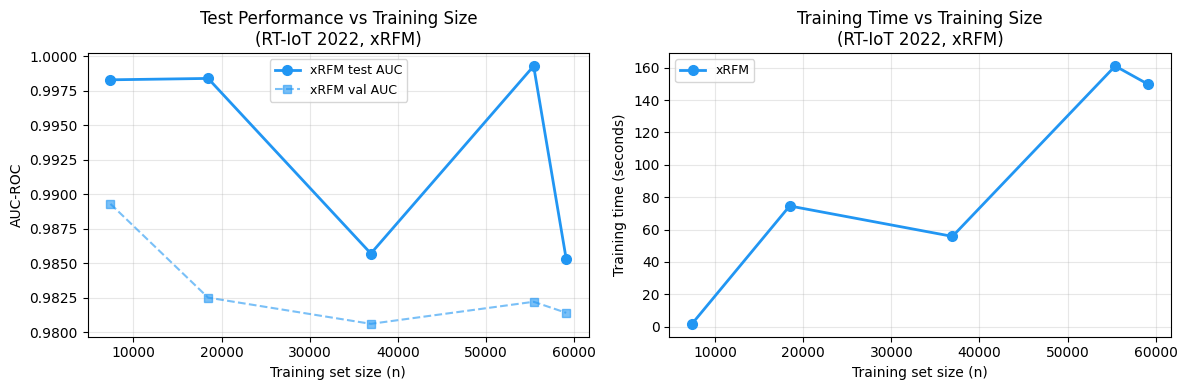

Learning curve plot saved → outputs/xrfm_learning_curve.png


In [10]:
# ========== LEARNING CURVE: xRFM on RT-IoT 2022 (n > 10,000) ==========
#
# Design
#   • Dataset   : RT-IoT 2022 (n ≈ 98 k training samples, multi-class classification)
#   • Subsamples: training set stratified-subsampled at SAMPLE_FRACS
#   • Val / Test sets are FIXED across all fractions (same held-out splits)
#   • Best hyperparams (from xrfm_best_params.json) used for all runs
#   • Records: test AUC, val AUC, training time per fraction
#
# Outputs
#   • outputs/xrfm_learning_curve_rt_iot.csv   ← machine-readable for combined plot
#   • outputs/xrfm_learning_curve.png          ← two-panel figure (AUC vs n, time vs n)
#
# NOTE: This cell only plots xRFM's curve.
#       Merge with XGBoost / RF curves from teammates to produce the combined report figure.

import json

CURVE_DS     = "rt_iot_2022"
# Max fraction fixed at 0.80 to avoid OOM on 4 GB VRAM.
SAMPLE_FRACS = [0.10, 0.25, 0.50, 0.75, 0.80]

# ── Load best params ──────────────────────────────────────────────────────────
best_params_path = OUTPUT_DIR / "xrfm_best_params.json"
if best_params_path.exists():
    with open(best_params_path) as f:
        _all_best = json.load(f)
    curve_params = _all_best.get(CURVE_DS, {})
    print(f"Best params from JSON : {curve_params}")
else:
    curve_params = {}
    print("xrfm_best_params.json not found – using default params.")

cfg_rt = CATALOG[CURVE_DS]
X_train_rt, X_val_rt, X_test_rt, y_train_rt, y_val_rt, y_test_rt, info_rt = \
    load_and_split(cfg_rt)
cat_info_rt = info_rt.get("categorical_info")

n_full = len(X_train_rt)
print(f"\nDataset       : {cfg_rt['label']}")
print(f"Full train n  : {n_full}")
print(f"Val n         : {len(X_val_rt)}")
print(f"Test n        : {len(X_test_rt)}")
print(f"Sample fracs  : {SAMPLE_FRACS}")

# ── Resume support: load existing results to skip already-computed fractions ─
curve_path = OUTPUT_DIR / "xrfm_learning_curve_rt_iot.csv"
if curve_path.exists():
    _existing = pd.read_csv(curve_path)
    curve_records = _existing.to_dict("records")
    _done_fracs = set(_existing["fraction"].tolist())
    print(f"Loaded {len(curve_records)} existing record(s), will skip: {_done_fracs}")
else:
    curve_records = []
    _done_fracs = set()

for frac in SAMPLE_FRACS:
    if frac in _done_fracs:
        print(f"── Fraction {frac:.0%}  already done, skipping.")
        continue
    n_sub = max(int(n_full * frac), 200)
    _frac_device = DEVICE
    print(f"\n── Fraction {frac:.0%}  (n_train = {n_sub}, device={_frac_device}) ──")

    # Stratified subsample of training set
    if n_sub < n_full:
        idx, _ = train_test_split(
            np.arange(n_full), train_size=n_sub / n_full,
            random_state=SEED, stratify=y_train_rt
        )
        X_sub, y_sub = X_train_rt[idx], y_train_rt[idx]
    else:
        X_sub, y_sub = X_train_rt, y_train_rt

    mdl = build_xrfm(cfg_rt["task"], _frac_device, categorical_info=cat_info_rt, **curve_params)

    t0        = time.time()
    mdl.fit(X_sub, y_sub, X_val_rt, y_val_rt)
    train_sec = round(time.time() - t0, 2)

    def _auc_or_acc(m, X, y):
        try:
            p = to_numpy(m.predict_proba(X))
            if p.ndim == 1:
                return round(roc_auc_score(y, p), 4)
            if p.shape[1] == 2:
                return round(roc_auc_score(y, p[:, 1]), 4)
            return round(roc_auc_score(y, p, multi_class="ovr"), 4)
        except Exception:
            return round(accuracy_score(y, to_numpy(m.predict(X))), 4)

    test_auc = _auc_or_acc(mdl, X_test_rt, y_test_rt)
    val_auc  = _auc_or_acc(mdl, X_val_rt,  y_val_rt)

    rec = {
        "model":     "xRFM",
        "fraction":  frac,
        "n_train":   n_sub,
        "train_sec": train_sec,
        "val_auc":   val_auc,
        "test_auc":  test_auc,
    }
    curve_records.append(rec)
    print(f"   train={train_sec}s  val_auc={val_auc:.4f}  test_auc={test_auc:.4f}")

    # Free GPU memory before the next (larger) fraction to prevent OOM accumulation
    del mdl
    if _frac_device == "cuda":
        torch.cuda.empty_cache()

# ── Save ──────────────────────────────────────────────────────────────────────
curve_df = pd.DataFrame(curve_records).sort_values("fraction").reset_index(drop=True)
curve_df.to_csv(curve_path, index=False)
print(f"\nLearning curve data → {curve_path}")
display(curve_df)

# ── Plot (xRFM only; teammates add XGBoost / RF lines to this figure) ────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(curve_df["n_train"], curve_df["test_auc"], "o-", color="#2196F3",
         linewidth=2, markersize=7, label="xRFM test AUC")
ax1.plot(curve_df["n_train"], curve_df["val_auc"],  "s--", color="#2196F3",
         linewidth=1.5, markersize=6, alpha=0.6, label="xRFM val AUC")
ax1.set_xlabel("Training set size (n)")
ax1.set_ylabel("AUC-ROC")
ax1.set_title("Test Performance vs Training Size\n(RT-IoT 2022, xRFM)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(curve_df["n_train"], curve_df["train_sec"], "o-", color="#2196F3",
         linewidth=2, markersize=7, label="xRFM")
ax2.set_xlabel("Training set size (n)")
ax2.set_ylabel("Training time (seconds)")
ax2.set_title("Training Time vs Training Size\n(RT-IoT 2022, xRFM)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xrfm_learning_curve.png", dpi=150)
plt.show()
print("Learning curve plot saved → outputs/xrfm_learning_curve.png")